<a href="https://colab.research.google.com/github/ssoyyoungg/practice/blob/main/Medical_Vessel_Morphology.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [108]:
!pip install torch torchvision matplotlib opencv-python

In [109]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt

Dataset 클래스

In [110]:
class VesselDataset(Dataset):
    def __init__(self, image_dir, mask_dir, transform=None):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.images = os.listdir(image_dir)
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = os.path.join(self.image_dir, self.images[idx])
        mask_path = os.path.join(self.mask_dir, self.images[idx])

        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(mask_path, 0)

        image = cv2.resize(image,(256,256))
        mask = cv2.resize(mask,(256,256))

        image = image / 255.0
        mask = mask / 255.0

        image = torch.tensor(image).permute(2,0,1).float()
        mask = torch.tensor(mask).unsqueeze(0).float()

        return image, mask

U-Net 모델

In [111]:
class DoubleConv(nn.Module):
    def __init__(self,in_ch,out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch,out_ch,3,padding=1),
            nn.ReLU(),
            nn.Conv2d(out_ch,out_ch,3,padding=1),
            nn.ReLU()
        )

    def forward(self,x):
        return self.conv(x)


class UNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.down1 = DoubleConv(3,64)
        self.pool1 = nn.MaxPool2d(2)

        self.down2 = DoubleConv(64,128)
        self.pool2 = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(128,256)

        self.up1 = nn.ConvTranspose2d(256,128,2,stride=2)
        self.conv1 = DoubleConv(256,128)

        self.up2 = nn.ConvTranspose2d(128,64,2,stride=2)
        self.conv2 = DoubleConv(128,64)

        self.final = nn.Conv2d(64,1,1)

    def forward(self,x):

        d1 = self.down1(x)
        p1 = self.pool1(d1)

        d2 = self.down2(p1)
        p2 = self.pool2(d2)

        b = self.bottleneck(p2)

        u1 = self.up1(b)
        u1 = torch.cat([u1,d2],dim=1)
        u1 = self.conv1(u1)

        u2 = self.up2(u1)
        u2 = torch.cat([u2,d1],dim=1)
        u2 = self.conv2(u2)

        return torch.sigmoid(self.final(u2))

In [112]:
import os

os.makedirs("images",exist_ok=True)
os.makedirs("masks",exist_ok=True)

In [113]:
import os
import cv2
import numpy as np

os.makedirs("images", exist_ok=True)
os.makedirs("masks", exist_ok=True)

for i in range(20):
    img = np.zeros((256, 256, 3), dtype=np.uint8)
    mask = np.zeros((256, 256), dtype=np.uint8)

    # 랜덤 선 여러 개 그리기 (혈관처럼)
    for _ in range(5):
        x1, y1 = np.random.randint(0, 256, size=2)
        x2, y2 = np.random.randint(0, 256, size=2)
        thickness = np.random.randint(2, 5)

        color = (
            np.random.randint(100, 255),
            np.random.randint(100, 255),
            np.random.randint(100, 255)
        )

        cv2.line(img, (x1, y1), (x2, y2), color, thickness)
        cv2.line(mask, (x1, y1), (x2, y2), 255, thickness)

    cv2.imwrite(f"images/{i}.png", img)
    cv2.imwrite(f"masks/{i}.png", mask)

print("샘플 데이터 생성 완료")

샘플 데이터 생성 완료


데이터 로드

In [114]:
dataset = VesselDataset(
    image_dir="images",
    mask_dir="masks"
)

loader = DataLoader(dataset,batch_size=4,shuffle=True)

In [115]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = UNet().to(device)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 5

for epoch in range(epochs):
    total_loss = 0

    for img, mask in loader:
        img = img.to(device)
        mask = mask.to(device)

        pred = model(img)

        loss = criterion(pred, mask)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1} Loss {total_loss/len(loader):.4f}")

Epoch 1 Loss 0.6221
Epoch 2 Loss 0.2068
Epoch 3 Loss 0.0657
Epoch 4 Loss 0.0297
Epoch 5 Loss 0.0191


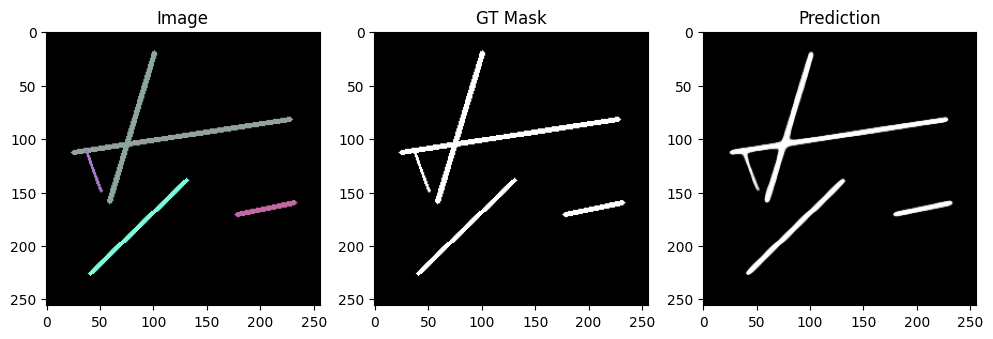

In [116]:
img, mask = dataset[0]

model.eval()
with torch.no_grad():
    pred = model(img.unsqueeze(0).to(device))
    pred = pred.cpu().squeeze().numpy()

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Image")
plt.imshow(img.permute(1,2,0))

plt.subplot(1,3,2)
plt.title("GT Mask")
plt.imshow(mask.squeeze(), cmap="gray")

plt.subplot(1,3,3)
plt.title("Prediction")
plt.imshow(pred, cmap="gray")

plt.show()

Dice Score 함수 만들기

In [117]:
def dice_score(pred, target, smooth=1e-6):
  pred = pred > 0.5
  target = target > 0.5

  intersection = (pred & target).sum()
  union = pred.sum() + target.sum()

  dice = (2 * intersection + smooth) / (union + smooth)
  return dice

Dice Score계산 실습

In [118]:
img, mask = dataset[0]

model.eval()
with torch.no_grad():
  pred = model(img.unsqueeze(0).to(device))
  pred = pred.cpu().squeeze().numpy()
dice = dice_score(pred, mask.squeeze().numpy())

print("Dice Score:", dice)

Dice Score: 0.960705104671189


전체 데이터 Dice 계산

In [119]:
total_dice = []

model.eval()

with torch.no_grad():
  for img, mask in dataset:
    pred = model(img.unsqueeze(0).to(device))
    pred = pred.cpu().squeeze().numpy()
    dice = dice_score(pred, mask.squeeze().numpy())
    total_dice.append(dice)
print("Average Dice Score:", np.mean(total_dice))

Average Dice Score: 0.9364841465947524


In [120]:
!pip install scikit-image

In [121]:
from skimage.morphology import skeletonize

skeleton 추출

In [122]:
img, mask = dataset[0]
model.eval()

with torch.no_grad():
  pred = model(img.unsqueeze(0).to(device))
  pred = pred.cpu().squeeze().numpy()

binary = pred > 0.5
skeleton = skeletonize(binary)

길이 계산

In [123]:
vessel_length = skeleton.sum()

print("Vessel Length (pixel):", vessel_length)

Vessel Length (pixel): 516


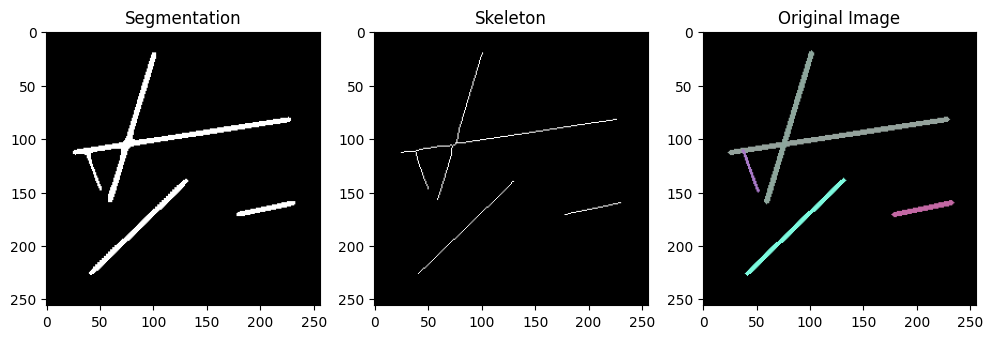

In [124]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Segmentation")
plt.imshow(binary, cmap="gray")

plt.subplot(1,3,2)
plt.title("Skeleton")
plt.imshow(skeleton, cmap="gray")

plt.subplot(1,3,3)
plt.title("Original Image")
plt.imshow(img.permute(1,2,0))

plt.show()

skeleton 픽셀 좌표 추출

In [125]:
import numpy as np

coords = np.column_stack(np.where(skeleton))

print("skeleton pixel count :", len(coords))

skeleton pixel count : 516


길이 계산

In [126]:
vessel_length = skeleton.sum()
print("Vessel length (pixels):", vessel_length)

Vessel length (pixels): 516


Branch Point(주변 픽셀이 3개 이상 연결된 지점)

In [127]:
from scipy.signal import convolve2d

kernel = np.array([
    [1,1,1],
    [1,10,1],
    [1,1,1]
])

neighbor_count = convolve2d(skeleton.astype(int), kernel, mode="same")

branch_points = (neighbor_count >= 13)

print("Branch points:", branch_points.sum())

Branch points: 7


EndPoint 찾기

In [128]:
endpoint = (neighbor_count == 11)
print("Endpoints : ", endpoint.sum())

Endpoints :  9


시각화

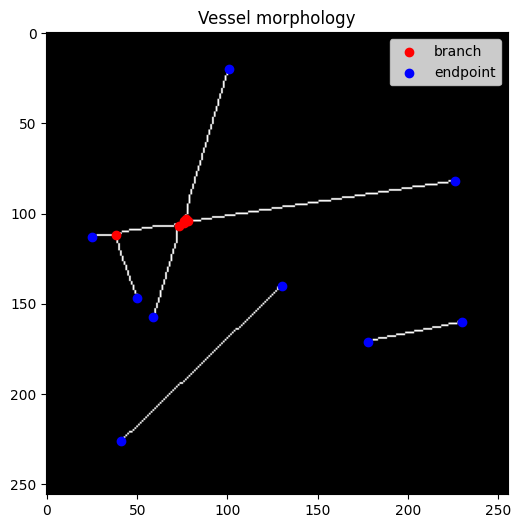

In [129]:
plt.figure(figsize=(6,6))
plt.imshow(skeleton, cmap="gray")

y,x = np.where(branch_points)
plt.scatter(x,y,color="red",label="branch")

y,x = np.where(endpoint)
plt.scatter(x,y,color="blue",label="endpoint")

plt.legend()
plt.title("Vessel morphology")
plt.show()

skeleton 좌표 시각화

In [130]:
coords = np.column_stack(np.where(skeleton))

print("좌푝 개수 : ", len(coords))
print(coords[:10])

좌푝 개수 :  516
[[ 20 101]
 [ 21 101]
 [ 22 100]
 [ 23 100]
 [ 24  99]
 [ 25  99]
 [ 26  99]
 [ 27  98]
 [ 28  98]
 [ 29  98]]


가장 긴 선분 하나 선택

In [131]:
from scipy import ndimage

labeled, num_features = ndimage.label(skeleton)

print("Connected components:", num_features)

Connected components: 181


각선분 크기 확인

In [132]:
component_sizes = []
for i in range(1, num_features + 1):
    size = np.sum(labeled == i)
    component_sizes.append(size)
    print(f"Component {i}: {size}")

Component 1: 2
Component 2: 2
Component 3: 3
Component 4: 4
Component 5: 3
Component 6: 3
Component 7: 4
Component 8: 3
Component 9: 3
Component 10: 4
Component 11: 3
Component 12: 3
Component 13: 4
Component 14: 3
Component 15: 3
Component 16: 4
Component 17: 3
Component 18: 3
Component 19: 3
Component 20: 4
Component 21: 4
Component 22: 6
Component 23: 3
Component 24: 7
Component 25: 7
Component 26: 6
Component 27: 3
Component 28: 7
Component 29: 6
Component 30: 7
Component 31: 5
Component 32: 6
Component 33: 7
Component 34: 6
Component 35: 7
Component 36: 6
Component 37: 6
Component 38: 7
Component 39: 7
Component 40: 6
Component 41: 7
Component 42: 6
Component 43: 7
Component 44: 14
Component 45: 6
Component 46: 7
Component 47: 6
Component 48: 2
Component 49: 2
Component 50: 12
Component 51: 2
Component 52: 6
Component 53: 7
Component 54: 8
Component 55: 4
Component 56: 3
Component 57: 11
Component 58: 3
Component 59: 4
Component 60: 4
Component 61: 3
Component 62: 3
Component 63: 

가장 긴 선분 선택

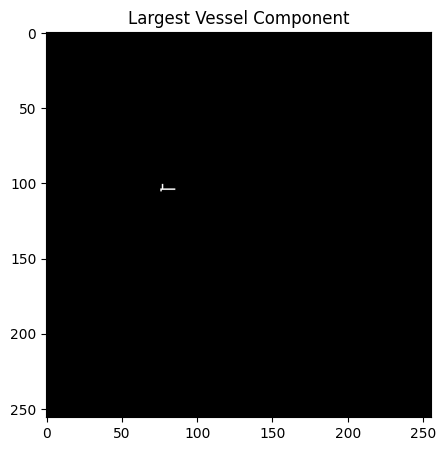

In [133]:
largest_idx = np.argmax(component_sizes) + 1
largest_component = (labeled == largest_idx)

plt.figure(figsize=(5,5))
plt.imshow(largest_component, cmap="gray")
plt.title("Largest Vessel Component")
plt.show()

선택한 선분의 endpoint 찾기

In [134]:
kernel = np.array([
    [1,1,1],
    [1,10,1],
    [1,1,1]
])

neighbor_count_comp = convolve2d(largest_component.astype(int), kernel, mode="same")
endpoints_comp = (neighbor_count_comp == 11)

y_ep, x_ep = np.where(endpoints_comp)
print("Endpoints:", list(zip(x_ep, y_ep)))

Endpoints: [(np.int64(77), np.int64(101)), (np.int64(85), np.int64(104))]


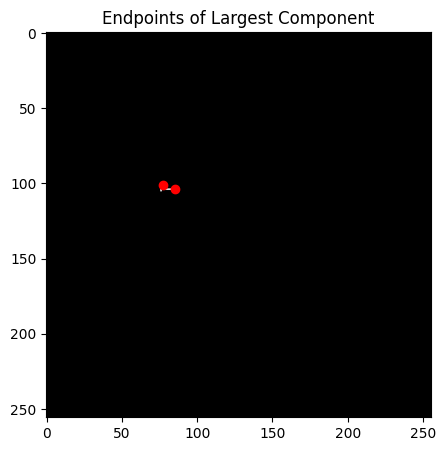

In [135]:
plt.figure(figsize=(5,5))
plt.imshow(largest_component, cmap="gray")
plt.scatter(x_ep, y_ep, color="red")
plt.title("Endpoints of Largest Component")
plt.show()

직선 거리 계산

In [136]:
import math

p1 = np.array([y_ep[0], x_ep[0]])
p2 = np.array([y_ep[1], x_ep[1]])

straight_distance = np.linalg.norm(p1 - p2)
print("Straight distance:", straight_distance)

Straight distance: 8.54400374531753


실제 길이 근사

In [137]:
path_length = largest_component.sum()
print("Path length (approx):", path_length)

Path length (approx): 14


굴곡 계산(Tortuosity)

In [138]:
tortuosity = path_length / (straight_distance + 1e-8)
print("Tortuosity :", tortuosity)

Tortuosity : 1.6385760588280196


직선과 곡선의 tortusity 비교

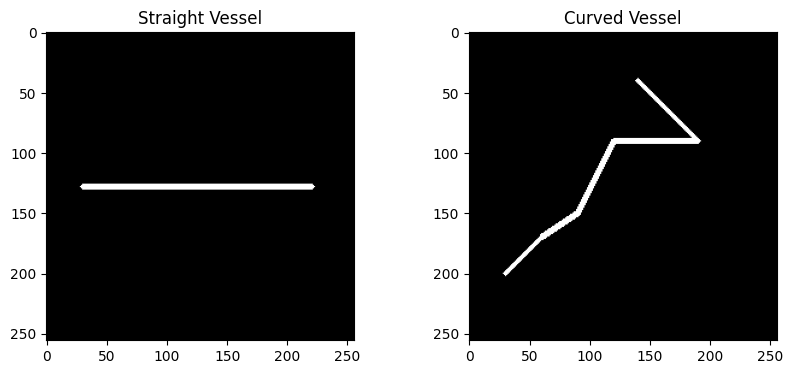

In [139]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# 빈 mask 생성
straight_mask = np.zeros((256, 256), dtype=np.uint8)
curved_mask = np.zeros((256, 256), dtype=np.uint8)

# 1) 직선 혈관
cv2.line(straight_mask, (30, 128), (220, 128), 255, 4)

# 2) 곡선 혈관 (polyline)
curve_points = np.array([
    [30, 200],
    [60, 170],
    [90, 150],
    [120, 90],
    [190, 90],
    [140, 40]
], dtype=np.int32)

cv2.polylines(curved_mask, [curve_points], isClosed=False, color=255, thickness=4)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.title("Straight Vessel")
plt.imshow(straight_mask, cmap="gray")

plt.subplot(1,2,2)
plt.title("Curved Vessel")
plt.imshow(curved_mask, cmap="gray")

plt.show()

skeleton 추출

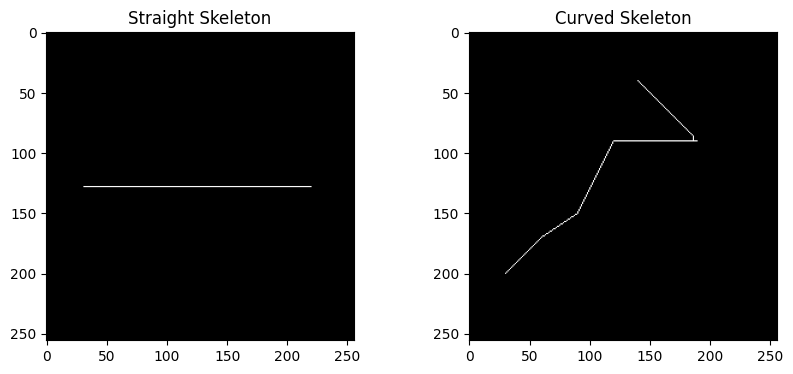

In [140]:
from skimage.morphology import skeletonize

straight_skeleton = skeletonize(straight_mask > 0)
curved_skeleton = skeletonize(curved_mask > 0)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.title("Straight Skeleton")
plt.imshow(straight_skeleton, cmap="gray")

plt.subplot(1,2,2)
plt.title("Curved Skeleton")
plt.imshow(curved_skeleton, cmap="gray")

plt.show()

endpoint 찾는 함수

In [141]:
from scipy.signal import convolve2d

def find_endpoints(skel):
    kernel = np.array([
        [1,1,1],
        [1,10,1],
        [1,1,1]
    ])
    neighbor_count = convolve2d(skel.astype(int), kernel, mode="same")
    endpoints = (neighbor_count == 11)
    y, x = np.where(endpoints)
    return list(zip(y, x))

In [142]:
straight_endpoints = find_endpoints(straight_skeleton)
curved_endpoints = find_endpoints(curved_skeleton)

print("Straight endpoints:", straight_endpoints)
print("Curved endpoints:", curved_endpoints)

Straight endpoints: [(np.int64(128), np.int64(31)), (np.int64(128), np.int64(219))]
Curved endpoints: [(np.int64(40), np.int64(140)), (np.int64(90), np.int64(189)), (np.int64(200), np.int64(30))]


tortuosity 계산함수

In [143]:
straight_path = straight_skeleton.sum()
curved_path = curved_skeleton.sum()

straight_tort = straight_path / (straight_dist + 1e-8)
curved_tort = curved_path / (curved_dist + 1e-8)

print("\n=== Straight Vessel ===")
print("Straight distance:", straight_dist)
print("Path length:", straight_path)
print("Tortuosity:", straight_tort)

print("\n=== Curved Vessel ===")
print("Straight distance:", curved_dist)
print("Path length:", curved_path)
print("Tortuosity:", curved_tort)



=== Straight Vessel ===
Straight distance: 188.0
Path length: 189
Tortuosity: 1.0053191488826958

=== Curved Vessel ===
Straight distance: 194.164878389476
Path length: 240
Tortuosity: 1.2360628862353908


여러 곡선 만들고 tortuosity 확인

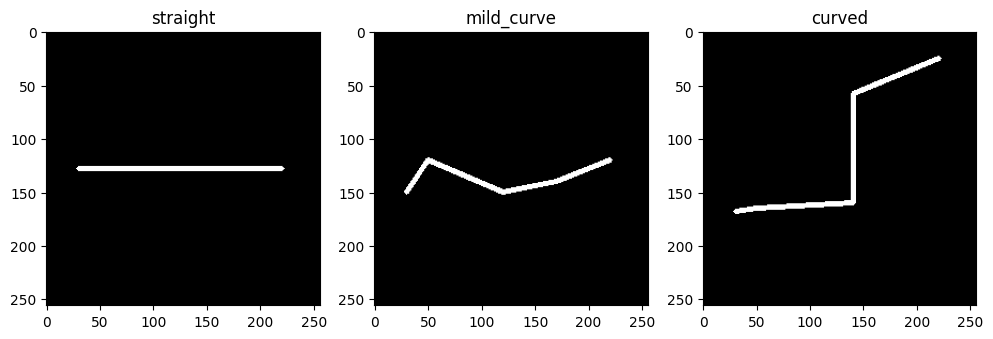

In [191]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

masks = {}

# 1. 직선 혈관
mask_straight = np.zeros((256, 256), dtype=np.uint8)
cv2.line(mask_straight, (30, 128), (220, 128), 255, 4)
masks["straight"] = mask_straight

# 2. 약간 굴곡진 혈관
mask_mild = np.zeros((256, 256), dtype=np.uint8)
mild_points = np.array([
    [30, 150],
    [50, 120],
    [120, 150],
    [170, 140],
    [220, 120]
], dtype=np.int32)
cv2.polylines(mask_mild, [mild_points], isClosed=False, color=255, thickness=4)
masks["mild_curve"] = mask_mild

# 3. 많이 굴곡진 혈관
mask_curved = np.zeros((256, 256), dtype=np.uint8)
curve_points = np.array([
    [30, 168],
    [50, 165],
    [140, 160],
    [140, 92],
    [140, 58],
    [220, 25]
], dtype=np.int32)
cv2.polylines(mask_curved, [curve_points], isClosed=False, color=255, thickness=4)
masks["curved"] = mask_curved

# 시각화
plt.figure(figsize=(12,4))
for i, (name, m) in enumerate(masks.items(), 1):
    plt.subplot(1, 3, i)
    plt.title(name)
    plt.imshow(m, cmap="gray")
plt.show()

skeleton 만들기

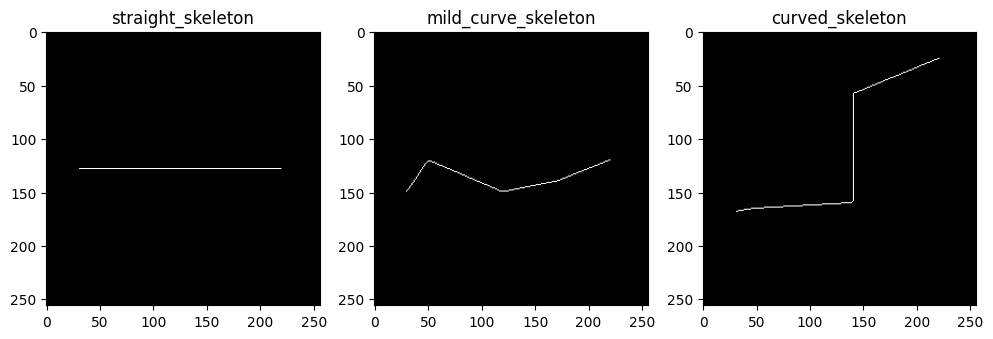

In [192]:
from skimage.morphology import skeletonize

skeletons = {}
for name, m in masks.items():
    skeletons[name] = skeletonize(m > 0)

plt.figure(figsize=(12,4))
for i, (name, sk) in enumerate(skeletons.items(), 1):
    plt.subplot(1, 3, i)
    plt.title(f"{name}_skeleton")
    plt.imshow(sk, cmap="gray")
plt.show()

endpoint 생성

In [193]:
from scipy.signal import convolve2d
import itertools

def find_endpoints_and_farthest(skel):
    kernel = np.array([
        [1,1,1],
        [1,10,1],
        [1,1,1]
    ])

    neighbor_count = convolve2d(skel.astype(int), kernel, mode="same")
    endpoints = (neighbor_count == 11)

    y, x = np.where(endpoints)
    endpoint_list = list(zip(y, x))

    max_dist = 0
    best_pair = None

    for p1, p2 in itertools.combinations(endpoint_list, 2):
        p1 = np.array(p1)
        p2 = np.array(p2)
        dist = np.linalg.norm(p1 - p2)

        if dist > max_dist:
            max_dist = dist
            best_pair = (p1, p2)

    return endpoint_list, best_pair, max_dist

tortuosity 계산

In [194]:
def compute_tortuosity_from_skeleton(skel):
    endpoints, pair, straight_distance = find_endpoints_and_farthest(skel)

    if pair is None:
        return None

    path_length = skel.sum()
    tortuosity = path_length / (straight_distance + 1e-8)

    return {
        "num_endpoints": len(endpoints),
        "straight_distance": float(straight_distance),
        "path_length": int(path_length),
        "tortuosity": float(tortuosity)
    }

In [195]:
results = {}

for name, sk in skeletons.items():
    results[name] = compute_tortuosity_from_skeleton(sk)

for name, result in results.items():
    print(f"=== {name} ===")
    for k, v in result.items():
        print(f"{k}: {v}")
    print()

=== straight ===
num_endpoints: 2
straight_distance: 188.0
path_length: 189
tortuosity: 1.0053191488826958

=== mild_curve ===
num_endpoints: 2
straight_distance: 192.20041623263984
path_length: 199
tortuosity: 1.035377570404302

=== curved ===
num_endpoints: 2
straight_distance: 237.00210969525145
path_length: 290
tortuosity: 1.2236177996924145



분지혈관 만들기

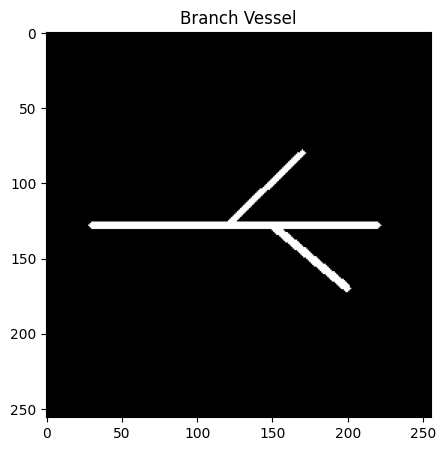

In [196]:
branch_mask = np.zeros((256,256), dtype=np.uint8)

# main vessel
cv2.line(branch_mask, (30,128), (220,128), 255, 4)

# branch 1
cv2.line(branch_mask, (120,128), (170,80), 255, 4)

# branch 2
cv2.line(branch_mask, (150,128), (200,170), 255, 4)

plt.figure(figsize=(5,5))
plt.title("Branch Vessel")
plt.imshow(branch_mask, cmap="gray")
plt.show()

skeleton 추출

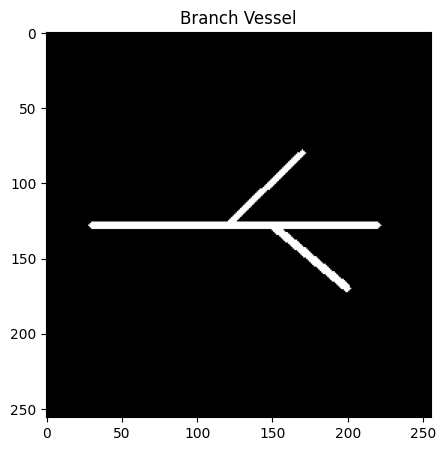

In [197]:
branch_mask = np.zeros((256,256), dtype=np.uint8)

# main vessel
cv2.line(branch_mask, (30,128), (220,128), 255, 4)

# branch 1
cv2.line(branch_mask, (120,128), (170,80), 255, 4)

# branch 2
cv2.line(branch_mask, (150,128), (200,170), 255, 4)

plt.figure(figsize=(5,5))
plt.title("Branch Vessel")
plt.imshow(branch_mask, cmap="gray")
plt.show()

branch point 찾기

In [199]:
from skimage.morphology import skeletonize

branch_skeleton = skeletonize(branch_mask > 0)

kernel = np.array([
    [1,1,1],
    [1,10,1],
    [1,1,1]
])

neighbor_count = convolve2d(branch_skeleton.astype(int), kernel, mode="same")

branch_points = neighbor_count >= 13

y_branch, x_branch = np.where(branch_points)

print("Branch points:", len(y_branch))

Branch points: 4


endpoint 찾기

In [200]:
endpoints = neighbor_count == 11

y_end, x_end = np.where(endpoints)

print("Endpoints:", len(y_end))

Endpoints: 4


시각화

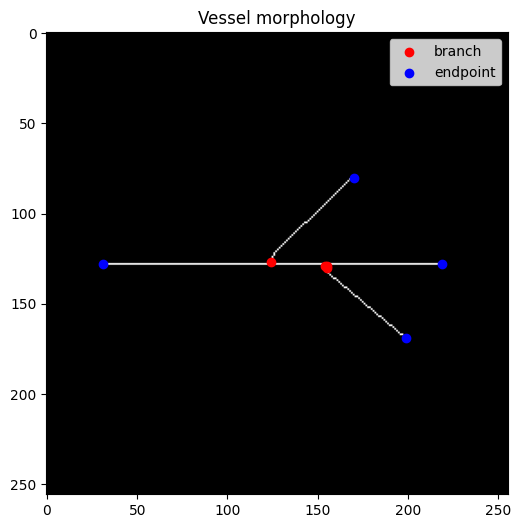

In [201]:
plt.figure(figsize=(6,6))

plt.imshow(branch_skeleton, cmap="gray")

plt.scatter(x_branch, y_branch, color="red", label="branch")
plt.scatter(x_end, y_end, color="blue", label="endpoint")

plt.legend()
plt.title("Vessel morphology")
plt.show()

morphology feature

In [202]:
from scipy.signal import convolve2d
import numpy as np
import itertools

def compute_morphology_features(skel):
    kernel = np.array([
        [1,1,1],
        [1,10,1],
        [1,1,1]
    ])

    neighbor_count = convolve2d(skel.astype(int), kernel, mode="same")

    # endpoint: 주변 연결 1개
    endpoints = (neighbor_count == 11)
    y_end, x_end = np.where(endpoints)
    endpoint_list = list(zip(y_end, x_end))

    # branch point: 주변 연결 3개 이상
    branch_points = (neighbor_count >= 13)
    y_branch, x_branch = np.where(branch_points)
    branch_count = len(y_branch)

    # skeleton 길이
    path_length = int(skel.sum())

    # 가장 먼 endpoint pair 찾기
    max_dist = 0
    best_pair = None

    for p1, p2 in itertools.combinations(endpoint_list, 2):
        p1 = np.array(p1)
        p2 = np.array(p2)
        dist = np.linalg.norm(p1 - p2)

        if dist > max_dist:
            max_dist = dist
            best_pair = (p1, p2)

    straight_distance = float(max_dist) if best_pair is not None else 0.0
    tortuosity = path_length / (straight_distance + 1e-8) if straight_distance > 0 else None

    # branch density
    branch_density = branch_count / (path_length + 1e-8)

    return {
        "path_length": path_length,
        "num_endpoints": len(endpoint_list),
        "num_branch_points": branch_count,
        "straight_distance": straight_distance,
        "tortuosity": tortuosity,
        "branch_density": branch_density
    }

세가지 선에 대해 계산

In [203]:
results = {
    "straight": compute_morphology_features(straight_skeleton),
    "curved": compute_morphology_features(curved_skeleton),
    "branch": compute_morphology_features(branch_skeleton)
}

for name, result in results.items():
    print(f"=== {name} ===")
    for k, v in result.items():
        print(f"{k}: {v}")
    print()

=== straight ===
path_length: 189
num_endpoints: 2
num_branch_points: 0
straight_distance: 188.0
tortuosity: 1.0053191488826958
branch_density: 0.0

=== curved ===
path_length: 240
num_endpoints: 3
num_branch_points: 4
straight_distance: 194.164878389476
tortuosity: 1.2360628862353908
branch_density: 0.016666666665972222

=== branch ===
path_length: 285
num_endpoints: 4
num_branch_points: 4
straight_distance: 188.0
tortuosity: 1.5159574467278745
branch_density: 0.014035087718805786



In [204]:
import pandas as pd

df = pd.DataFrame(results).T
print(df)

          path_length  num_endpoints  num_branch_points  straight_distance  \
straight        189.0            2.0                0.0         188.000000   
curved          240.0            3.0                4.0         194.164878   
branch          285.0            4.0                4.0         188.000000   

          tortuosity  branch_density  
straight    1.005319        0.000000  
curved      1.236063        0.016667  
branch      1.515957        0.014035  
